# 1. Import Library

In [1]:
from pathlib import Path
import os
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# 2. Load Dataset Path

In [2]:
DATASET_PATH = Path("../Dataset")

TRAIN_PATH = DATASET_PATH / "Training"
TEST_PATH = DATASET_PATH / "Testing"

print(f"Training Path : {TRAIN_PATH}")
print(f"Testing Path  : {TEST_PATH}")

Training Path : ..\Dataset\Training
Testing Path  : ..\Dataset\Testing


In [3]:
print("Training Exists :", TRAIN_PATH.exists())
print("Testing Exists  :", TEST_PATH.exists())

Training Exists : True
Testing Exists  : True


# 3. Count Images

In [4]:
#cek kelas
classes = sorted(
    [folder.name for folder in TRAIN_PATH.iterdir() if folder.is_dir()]
)

print("Classes:")
for i, class_name in enumerate(classes, start=1):
    print(f"{i}. {class_name}")

Classes:
1. glioma_tumor
2. meningioma_tumor
3. no_tumor
4. pituitary_tumor


In [5]:
#cek komposisi dataset training
train_counts = {}

for class_name in classes:
    train_counts[class_name] = len(list((TRAIN_PATH / class_name).glob("*")))

print("Training Dataset")
for class_name, total in train_counts.items():
    print(f"{class_name:<20}: {total} images")

Training Dataset
glioma_tumor        : 826 images
meningioma_tumor    : 822 images
no_tumor            : 395 images
pituitary_tumor     : 827 images


In [6]:
#cek komposisi dataset testing
test_counts = {}

for class_name in classes:
    test_counts[class_name] = len(list((TEST_PATH / class_name).glob("*")))

print("Testing Dataset")
for class_name, total in test_counts.items():
    print(f"{class_name:<20}: {total} images")

Testing Dataset
glioma_tumor        : 100 images
meningioma_tumor    : 115 images
no_tumor            : 105 images
pituitary_tumor     : 74 images


# 4. Visualize Sample Images

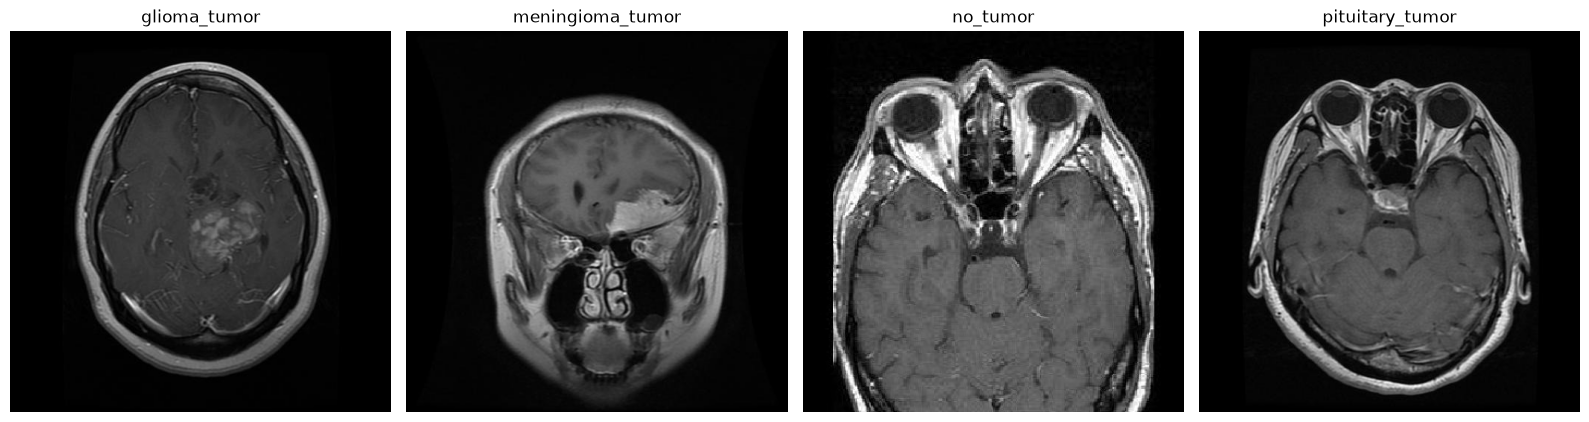

In [7]:
fig, axes = plt.subplots(1, len(classes), figsize=(16, 5))

for ax, class_name in zip(axes, classes):
    image_path = next((TRAIN_PATH / class_name).glob("*"))

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

# 5. Analyze Image Size

In [8]:
for class_name in classes:
    image_path = next((TRAIN_PATH / class_name).glob("*"))

    image = Image.open(image_path)

    print(f"Class : {class_name}")
    print(f"Size  : {image.size}")
    print(f"Mode  : {image.mode}")
    print("-" * 30)

Class : glioma_tumor
Size  : (512, 512)
Mode  : RGB
------------------------------
Class : meningioma_tumor
Size  : (512, 512)
Mode  : RGB
------------------------------
Class : no_tumor
Size  : (350, 350)
Mode  : RGB
------------------------------
Class : pituitary_tumor
Size  : (512, 512)
Mode  : RGB
------------------------------


In [9]:
image_sizes = []
image_modes = []

for class_name in classes:
    for image_path in (TRAIN_PATH / class_name).glob("*"):
        image = Image.open(image_path)

        image_sizes.append(image.size)
        image_modes.append(image.mode)

In [10]:
from collections import Counter

size_counter = Counter(image_sizes)
mode_counter = Counter(image_modes)

print("Most Common Image Sizes")
print(size_counter.most_common())

print("\nImage Modes")
print(mode_counter)

Most Common Image Sizes
[((512, 512), 2309), ((236, 236), 46), ((225, 225), 30), ((442, 442), 15), ((256, 256), 15), ((630, 630), 14), ((350, 350), 10), ((201, 251), 8), ((236, 251), 4), ((236, 260), 4), ((235, 227), 4), ((236, 357), 4), ((236, 269), 4), ((220, 275), 4), ((228, 221), 3), ((455, 500), 3), ((236, 243), 3), ((236, 262), 3), ((428, 417), 3), ((234, 218), 3), ((416, 512), 3), ((853, 480), 3), ((213, 237), 2), ((554, 554), 2), ((212, 237), 2), ((200, 223), 2), ((341, 395), 2), ((200, 252), 2), ((210, 240), 2), ((236, 295), 2), ((235, 229), 2), ((234, 224), 2), ((209, 242), 2), ((236, 290), 2), ((210, 213), 2), ((233, 210), 2), ((236, 366), 2), ((236, 250), 2), ((235, 257), 2), ((236, 263), 2), ((655, 602), 2), ((852, 480), 2), ((236, 300), 2), ((236, 220), 2), ((201, 250), 2), ((420, 280), 2), ((1000, 583), 2), ((208, 242), 2), ((232, 217), 2), ((926, 649), 2), ((755, 824), 2), ((1024, 1024), 2), ((785, 848), 2), ((850, 872), 2), ((234, 225), 2), ((236, 257), 2), ((236, 231)

### Insight

- Seluruh gambar menggunakan format RGB sehingga tidak diperlukan konversi grayscale.
- Dataset memiliki ukuran gambar yang bervariasi, meskipun mayoritas berukuran 512×512.

Oleh karena itu, seluruh gambar akan di-resize ke ukuran yang seragam pada tahap preprocessing agar dapat diproses oleh model CNN.

# 6. Dataset Summary

In [11]:
import pandas as pd

total_train = sum(train_counts.values())
total_test = sum(test_counts.values())
total_images = total_train + total_test

summary = pd.DataFrame({
    "Information": [
        "Number of Classes",
        "Training Images",
        "Testing Images",
        "Total Images",
        "Color Mode",
        "Dominant Image Size",
        "Image Size Variation"
    ],
    "Value": [
        len(classes),
        total_train,
        total_test,
        total_images,
        mode_counter.most_common(1)[0][0],
        size_counter.most_common(1)[0][0],
        "Yes"
    ]
})

summary

,Information,Value
0,Number of Classes,4
1,Training Images,2870
2,Testing Images,394
3,Total Images,3264
4,Color Mode,RGB
5,Dominant Image Size,"(512, 512)"
6,Image Size Variation,Yes


# 7. Insight

### Dataset Overview
- Dataset terdiri dari **4 kelas**, yaitu Glioma Tumor, Meningioma Tumor, Pituitary Tumor, dan No Tumor.
- Total dataset terdiri dari **3264 citra MRI**, yang dibagi menjadi data training dan testing.
- Seluruh citra menggunakan format warna **RGB**.
Sebgaian besar citra memiliki ukuran **512 x 512 px**, namun masih terdapat variasi ukuran gambar.
- Oleh karena itu, seluruh gambar perlu melalui proses **resize** pada tahap preprocessing agar memiliki dimensi yang seragam sebelum digunakan untuk pelatihan model CNN.